# Pourri — real data head-to-head: simulation vs forecast-driven

Real Pourri data from `pourri_prod_sc` (see `extraction.sql` for provenance):
all 116 products with full monthly coverage, monthly grain, Oct 2025 - Jul 2026
(10 periods). CSV carries every forecast vintage (product x month x
snapshot_date); the sim uses the freshest vintage per month.

**Real:** actuals (monthly `t_outbound_shipment.shipped_qty` per product),
forecasts (`t_best_model_forecast` ensembler, freshest vintage per month,
deduped to latest plan run), `unit_cost` (shipments), `price`
(customer_effective_price supplementary series).

**Made up** (knobs, marked in code): lead times (1-3 months, cycled),
holding rate 2%/month of unit cost, order cost $250/PO, initial stock =
1 month of mean demand, margin floor of 15% of price where effective
price is at or below unit cost.

**Caveats:** 10 monthly periods is short — safety-stock error estimates and
cost totals are directional, not conclusive. A01/A02 items are lumpy
container-style shippers with near-garbage forecasts; kept deliberately to
show both methods on ugly real series.

In [1]:
from pathlib import Path

import pandas as pd

# CSV carries ALL forecast vintages: one row per product x month x
# snapshot_date (see extraction.sql). Keep `raw` at vintage grain for
# performance-by-snapshot analysis; the sim uses the freshest vintage per
# (product, month) = min timestep (latest snapshot breaks ties).
raw = pd.read_csv(Path("pourri_monthly.csv"))
fresh = (
    raw.sort_values(["timestep", "snapshot_date"], ascending=[True, False])
    .drop_duplicates(["product_id", "month"])
    .sort_values(["product_id", "month"])
)

# Per-product economics. unit_cost: mean of real monthly costs (null months
# had no shipments). Margin: price - unit_cost, floored at 15% of price where
# the effective price is at or below cost (made-up floor; a true negative
# stockout cost would reward stockouts).
econ = (
    fresh.groupby("product_id")
    .agg(unit_cost=("unit_cost", "mean"), price=("price", "first"),
         mean_demand=("actuals", "mean"))
    .round(3)
)
econ["margin"] = (econ["price"] - econ["unit_cost"]).clip(lower=0.15 * econ["price"]).round(3)

HOLDING_RATE = 0.02   # per month, made up
ORDER_COST = 250.0    # per PO, made up
LEAD_TIMES = {uid: 1 + i % 3 for i, uid in enumerate(sorted(econ.index))}  # 1-3 months, made up

df = fresh.assign(
    unique_id=fresh["product_id"],
    ds=fresh["month"],
    actuals=fresh["actuals"].astype(int),
    forecast=fresh["forecast"].round().astype(int),
    lead_time=fresh["product_id"].map(LEAD_TIMES),
    holding_cost_per_unit=fresh["product_id"].map((HOLDING_RATE * econ["unit_cost"]).round(4)),
    stockout_cost_per_unit=fresh["product_id"].map(econ["margin"]),
    order_cost_per_order=ORDER_COST,
    initial_on_hand=fresh["product_id"].map(econ["mean_demand"].round().astype(int)),
)[["unique_id", "ds", "actuals", "forecast", "lead_time", "holding_cost_per_unit",
   "stockout_cost_per_unit", "order_cost_per_order", "initial_on_hand"]]
df["current_stock"] = df["initial_on_hand"]
econ.assign(lead_time=pd.Series(LEAD_TIMES)).sort_values("mean_demand", ascending=False)

,unit_cost,price,mean_demand,margin,lead_time
product_id,,,,,
A01-30-8138-24,2.500,2.500,54103.2,0.375,1
CP13035,3.432,4.361,41318.5,0.929,3
MC13003,3.077,3.138,36088.2,0.471,1
ST9430,5.383,5.364,35393.4,0.805,1
MC12998,3.078,3.074,31129.6,0.461,3
...,...,...,...,...,...
PP-10ML-B,4.039,3.184,113.5,0.478,2
B01-118-9477-12,5.500,5.416,96.0,0.812,2
KT13171,5.632,5.750,64.8,0.862,3


In [2]:
# Contract check — same shape the loader enforces for real customer data.
REQUIRED_COLUMNS = {
    "unique_id", "ds", "forecast", "actuals",
    "lead_time", "holding_cost_per_unit", "stockout_cost_per_unit",
    "order_cost_per_order", "current_stock", "initial_on_hand",
}
CONSTANT_PER_ARTICLE = [
    "lead_time", "holding_cost_per_unit", "stockout_cost_per_unit",
    "order_cost_per_order", "current_stock", "initial_on_hand",
]
missing = REQUIRED_COLUMNS - set(df.columns)
assert not missing, f"contract violation — missing columns: {missing}"
per_article_nunique = df.groupby("unique_id")[CONSTANT_PER_ARTICLE].nunique()
assert (per_article_nunique == 1).all().all(), "contract violation — non-constant per-article column"
print(f"contract OK: {df['unique_id'].nunique()} products x {df.groupby('unique_id').size().iloc[0]} months")

contract OK: 116 products x 10 months


In [9]:
LEAD_TIMES

{'A01-30-8138-24': 1,
 'A02-30-8821-12': 2,
 'A02-30-9166-8': 3,
 'A05-150-9142-2': 1,
 'A05-150-9159-2': 2,
 'A05-50-6513-6': 3,
 'A05-50-8937-6': 1,
 'AZ10169': 2,
 'AZ12610': 3,
 'AZ12622': 1,
 'AZ12628': 2,
 'AZ12630': 3,
 'AZ12632': 1,
 'AZ9072': 2,
 'AZ9076': 3,
 'AZ9484': 1,
 'B01-118-9477-12': 2,
 'BB8496': 3,
 'BB9096': 1,
 'BB9620': 2,
 'BB9702': 3,
 'BD10544': 1,
 'BT12259': 2,
 'BT12264': 3,
 'BT9072': 1,
 'BT9076': 2,
 'BUC-12013': 3,
 'BUC-12014': 1,
 'BUC-12015': 2,
 'C02-30-9002-24': 3,
 'CP10169': 1,
 'CP10428': 2,
 'CP10666': 3,
 'CP11529': 1,
 'CP11623': 2,
 'CP12334': 3,
 'CP12479': 1,
 'CP12818': 2,
 'CP13001': 3,
 'CP13014': 1,
 'CP13026': 2,
 'CP13035': 3,
 'CP13054': 1,
 'CP13057': 2,
 'CP13163': 3,
 'CP13175': 1,
 'CP13274': 2,
 'KT10169': 3,
 'KT13008': 1,
 'KT13019': 2,
 'KT13171': 3,
 'KT9702': 1,
 'LV-004-CB': 2,
 'LV-004-CB-AMZ': 3,
 'LV-008-CB': 1,
 'LV-008-CB-AMZ': 2,
 'LV-016-BR': 3,
 'LV-10ML': 1,
 'LV-10ML-B': 2,
 'LVP-004-CB': 3,
 'LVP-004-CB-AMZ': 1

In [3]:
from replenishment import Portfolio

port = Portfolio.from_dataframe(df)
FACTOR = 1.65

# Head-to-head #1: simulation (point-forecast, horizon=1) vs forecast-driven
# (order-up-to target covers each item's own lead-time window).
sim_res = port.simulate(factor=FACTOR)                     # naive: horizon=1
fd_res = port.simulate(factor=FACTOR, horizon=LEAD_TIMES)  # lead-time-aware
len(sim_res), len(fd_res)

(116, 116)

In [4]:
comparison = pd.concat(
    {"simulation": sim_res.summary_frame(), "forecast_driven": fd_res.summary_frame()},
    axis=1,
).sort_index(axis=1)
comparison.insert(0, ("item", "lead_time"), pd.Series(LEAD_TIMES))
comparison.insert(1, ("item", "margin_per_unit"), econ["margin"])
comparison[("delta", "fill_rate")] = (
    comparison[("forecast_driven", "fill_rate")] - comparison[("simulation", "fill_rate")]
)
comparison[("delta", "total_cost")] = (
    comparison[("forecast_driven", "total_cost")] - comparison[("simulation", "total_cost")]
)
comparison.loc["MEAN"] = comparison.mean()
comparison.round(2)

item                 forecast_driven            \
               lead_time margin_per_unit     avg_on_hand fill_rate   
unique_id                                                            
A01-30-8138-24      1.00            0.38       112707.60      0.64   
A02-30-8821-12      2.00            0.84        20702.90      0.88   
A02-30-9166-8       3.00            1.02         2312.50      0.90   
A05-150-9142-2      1.00            1.97         5712.10      0.60   
A05-150-9159-2      2.00            1.79         6229.20      0.63   
...                  ...             ...             ...       ...   
TH-004-CB           2.00            1.22          276.10      0.47   
TH-004-CB-AMZ       3.00            1.32         6027.20      0.74   
TH-016-BR           1.00            2.20         1265.70      1.00   
TH-10ML             2.00            0.40         2602.00      0.90   
MEAN                1.99            2.10         9732.49      0.80   

                                                                    \
               holding_cost ordering_cost stockout_cost total_cost   
unique_id                                                            
A01-30-8138-24     56353.80       1250.00      73846.12  131449.92   
A02-30-8821-12     25319.65       2250.00      14708.51   42278.16   
A02-30-9166-8       3246.75       1500.00        714.42    5461.18   
A05-150-9142-2     15988.17       1250.00      20976.91   38215.08   
A05-150-9159-2     16731.63       1750.00      22267.85   40749.48   
...                     ...           ...           ...        ...   
TH-004-CB            527.90       2000.00       4882.78    7410.68   
TH-004-CB-AMZ      11409.49       2000.00       7629.90   21039.39   
TH-016-BR           3916.08       2250.00          0.00    6166.08   
TH-10ML             1329.62       2000.00        270.01    3599.63   
MEAN               11465.52       2090.52      32235.77   45791.81   

                simulation                                                     \
               avg_on_hand fill_rate holding_cost ordering_cost stockout_cost   
unique_id                                                                       
A01-30-8138-24   112707.60      0.64     56353.80       1250.00      73846.12   
A02-30-8821-12    11995.50      0.78     14670.50       1750.00      28151.81   
A02-30-9166-8       466.00      0.66       654.26       1500.00       2474.35   
A05-150-9142-2     5712.10      0.60     15988.17       1250.00      20976.91   
A05-150-9159-2     4539.80      0.47     12193.90       1500.00      31996.19   
...                    ...       ...          ...           ...           ...   
TH-004-CB           185.80      0.35       355.25       1750.00       5956.04   
TH-004-CB-AMZ      2769.70      0.67      5243.04       1750.00       9496.19   
TH-016-BR          1265.70      1.00      3916.08       2250.00          0.00   
TH-10ML            1392.70      0.90       711.67       2250.00        270.01   
MEAN               6230.64      0.71      6978.29       2030.17      51551.62   

                              delta             
               total_cost fill_rate total_cost  
unique_id                                       
A01-30-8138-24  131449.92      0.00       0.00  
A02-30-8821-12   44572.30      0.11   -2294.15  
A02-30-9166-8     4628.61      0.24     832.56  
A05-150-9142-2   38215.08      0.00       0.00  
A05-150-9159-2   45690.09      0.16   -4940.61  
...                   ...       ...        ...  
TH-004-CB         8061.29      0.12    -650.61  
TH-004-CB-AMZ    16489.23      0.06    4550.16  
TH-016-BR         6166.08      0.00       0.00  
TH-10ML           3231.68      0.00     367.95  
MEAN             60560.09      0.09  -14768.27  

[117 rows x 16 columns]

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


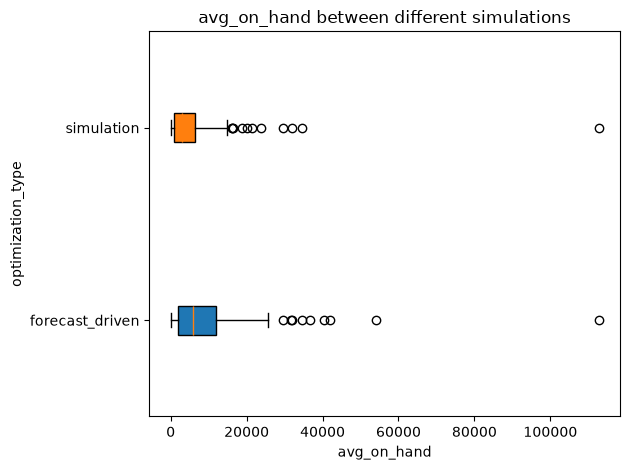

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


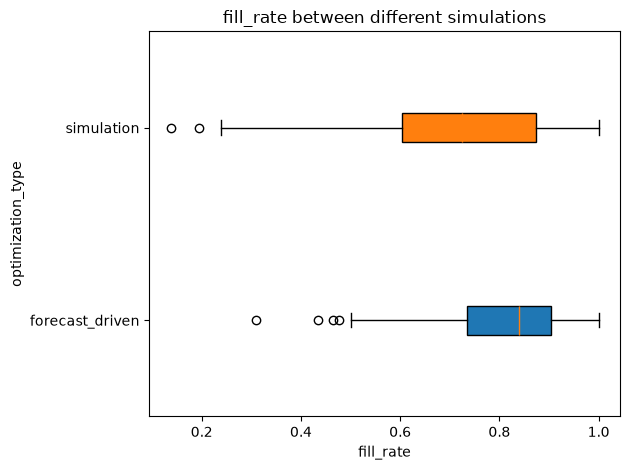

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


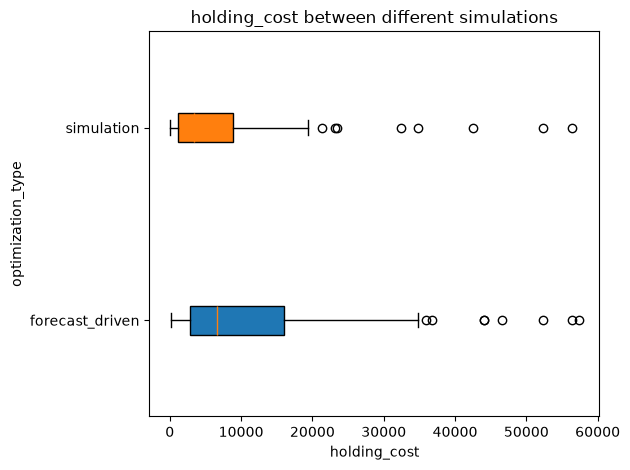

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


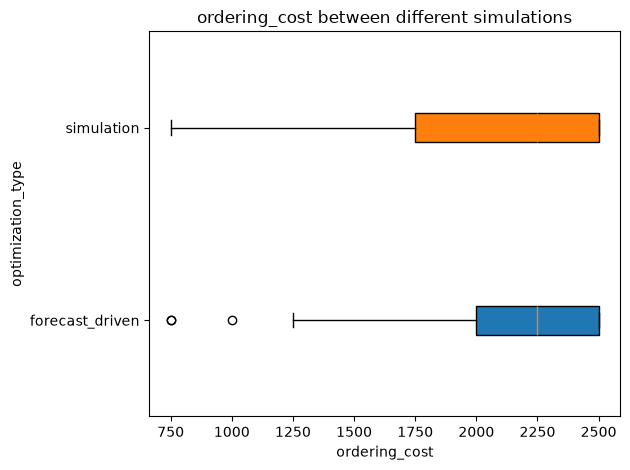

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


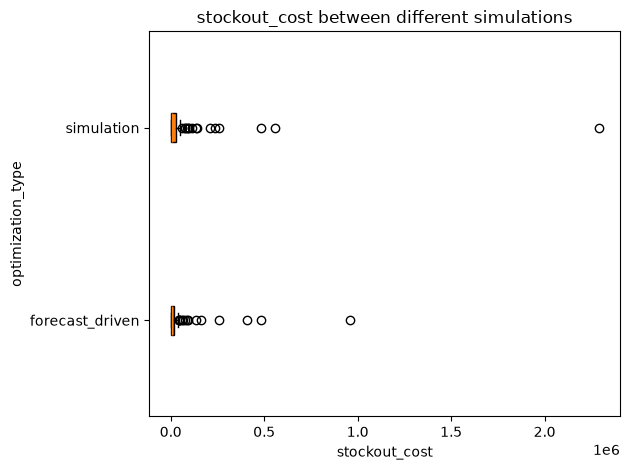

/var/folders/j6/v7r4q64d1zv5qj54955b_k_00000gn/T/ipykernel_91037/1572855257.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True)


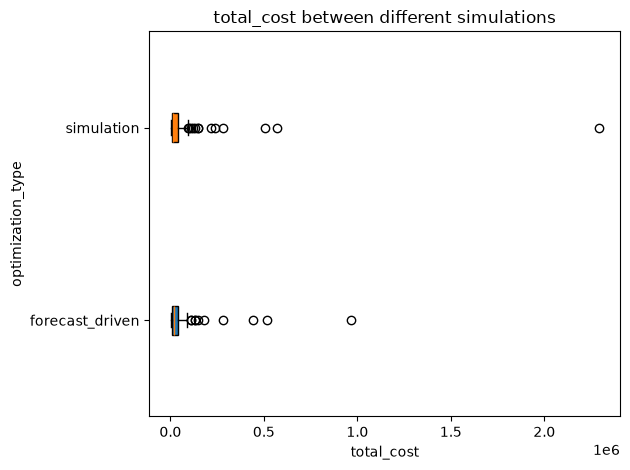

In [19]:
import matplotlib.pyplot as plt

stack_df = pd.concat(
    [comparison['simulation'].assign(optimization_type='simulation'),
     comparison['forecast_driven'].assign(optimization_type='forecast_driven')]
)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for col in stack_df.select_dtypes(include=['int', 'float']).columns:
    fig, ax = plt.subplots()
    grouped = stack_df.groupby('optimization_type')[col]
    labels, data = zip(*[(name, vals.dropna()) for name, vals in grouped])
    bp = ax.boxplot(data, vert=False, patch_artist=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
    ax.set_yticks(range(1, len(labels) + 1), labels)
    ax.set_xlabel(col)
    ax.set_ylabel('optimization_type')
    ax.set_title(f"{col} between different simulations")
    plt.tight_layout()
    plt.show()



In [20]:
# Head-to-head #2: service-level factor sweep. Does the ranking hold as the
# safety-stock knob moves, and where does each method's cost bottom out?
sweep_rows = []
for factor in [0.8, 1.28, 1.65, 2.33]:
    for label, kwargs in [("simulation", {}), ("forecast_driven", {"horizon": LEAD_TIMES})]:
        m = port.simulate(factor=factor, **kwargs).portfolio_metrics()
        sweep_rows.append({
            "factor": factor, "method": label,
            "mean_fill_rate": m["mean_fill_rate"], "total_cost": m["total_cost"],
            "total_stockout": m["total_stockout"], "total_holding": m["total_holding"],
        })
sweep = pd.DataFrame(sweep_rows).pivot(index="factor", columns="method")
sweep.round(2)

mean_fill_rate                 total_cost              total_stockout  \
method forecast_driven simulation forecast_driven  simulation forecast_driven   
factor                                                                          
0.80              0.77       0.64      5500672.37  8227001.14      4477117.89   
1.28              0.79       0.69      5326724.23  7425827.64      4001689.84   
1.65              0.80       0.71      5311850.44  7024970.10      3739349.82   
2.33              0.81       0.74      5503316.02  6816916.22      3453181.06   

                     total_holding              
method  simulation forecast_driven  simulation  
factor                                          
0.80    7583797.57       776554.48   406203.58  
1.28    6567740.17      1080034.39   621087.47  
1.65    5979988.38      1330000.62   809481.72  
2.33    5383966.52      1813384.95  1201949.70

In [6]:
# Head-to-head #3: stockout-dollar exposure by item — where does the naive
# method actually bleed money on Pourri's real demand?
bleed = pd.DataFrame({
    "lead_time": pd.Series(LEAD_TIMES),
    "margin": econ["margin"],
    "sim_stockout_$": {uid: s.stockout_cost for uid, s in sim_res.summaries.items()},
    "fd_stockout_$": {uid: s.stockout_cost for uid, s in fd_res.summaries.items()},
    "fd_extra_holding_$": {
        uid: fd_res[uid].summary.holding_cost - sim_res[uid].summary.holding_cost
        for uid in sim_res.summaries
    },
})
bleed["net_fd_gain_$"] = bleed["sim_stockout_$"] - bleed["fd_stockout_$"] - bleed["fd_extra_holding_$"]
bleed.sort_values("net_fd_gain_$", ascending=False).round(0)

,lead_time,margin,sim_stockout_$,fd_stockout_$,fd_extra_holding_$,net_fd_gain_$
MCTN-2OZ-LVP-ARC-V2,3,24.0,2288785.0,956944.0,8776.0,1323065.0
CP13035,3,1.0,209571.0,65616.0,4624.0,139331.0
MC11134,2,14.0,560238.0,407836.0,23759.0,128642.0
PP-016-BR,3,3.0,141444.0,47001.0,25689.0,68755.0
MC11123,3,4.0,235828.0,161201.0,15409.0,59219.0
...,...,...,...,...,...,...
MC13006,2,0.0,12530.0,12530.0,12424.0,-12424.0
MCTN-2OZ-LV-6PK,2,18.0,481093.0,481093.0,12434.0,-12434.0
AZ9076,3,2.0,27280.0,13136.0,27892.0,-13748.0
SET-10MLPACK,3,3.0,51626.0,51626.0,14796.0,-14796.0


## Conclusions (factor = 1.65, 116 items)

| | simulation | forecast_driven |
|---|---|---|
| mean fill rate | 0.71 | 0.80 (+0.09) |
| total cost, 116 items | $7.02M | $5.31M (−24%) |
| mean cost per item | $60.6k | $45.8k |

**The ranking survives real Pourri forecasts, the full portfolio, and the
whole service-level sweep.** At every factor (0.8 to 2.33) forecast-driven
costs $5.31M to 5.50M while the point-forecast method costs $6.82M to 8.23M.
Cranking safety stock cannot rescue the naive method, because its one-period
target structurally under-covers 2-3 month pipelines. The long tail dilutes
the relative gain (−40% on the old top-20 cut, −24% on all 116) but grows the
absolute gap.

**Lead_time = 1 items are exact ties by construction.** With a one-month lead
time, `forecast_horizon = lead_time = 1` makes the two policies identical
(~39 of 116 items, delta exactly 0). All separation comes from the 2-3 month
items: forecast-driven ordering is a lead-time play, not a universal win.

**Where the money is: high-margin, multi-month-lead items.**
MCTN-2OZ-LVP-ARC-V2 (margin ~$24, lead 3) alone nets ~$1.32M, CP13035 ~$139k,
MC11134 (margin ~$14) ~$129k. Thin-margin items move little either way — same
margin-times-lead-time interaction seen on the synthetic SBD run.

**Where forecast-driven loses: over-forecasted, fading items.** PP-004-CB-AMZ
(+$17k), SET-10MLPACK (+$15k), AZ9076 (+$14k), MC13006 (+$12k). The ensembler
systematically over-forecasts these (June 2026 vintage runs ~2x actuals across
much of the portfolio — a real data quirk worth its own investigation, now
enabled by the per-snapshot CSV grain). Forecast-driven ordering multiplies
that bias across the lead-time window: garbage forecast in, amplified garbage
out.

**Knobs exercised in #4/#5:** per-item calibrated factors (iso_service /
cost-min) and reorder-point vs order-up-to triggers. **Still unexercised:**
per-item MoQ (engine supports it, Pourri supplier minimums not in the data)
and per-snapshot forecast-bias correction feeding the policy.

## Head-to-head #4: per-item safety-stock optimization

The global factor (1.65 everywhere) is the crudest knob. Three per-item
alternatives, all on the forecast-driven policy:

- **iso_service** — cheapest-holding factor per item that keeps that item's fill
  rate at or above its global-1.65 baseline. Minimizes inventory subject to a
  service constraint, so it does NOT depend on the made-up stockout $ (margins).
  The "same service, less inventory" pitch.
- **cost_min_insample** — factor per item minimizing total cost on the full
  window. Peeks at the answer and trusts the stockout-$ knob: upper bound on what
  calibration can deliver (winner's curse — each item picks its luckiest factor),
  not an honest estimate.
- **cost_min_oos** — `calibration.optimize`: grid-search on the first 7 months,
  scored on the held-out last 3, then the chosen factors re-simulated on the full
  window for comparability. Honest selection, but 3 validation months per item is
  very thin — treat per-item factors as noisy.

Aggregate-safety columns (per-item optimization can flatter itself at portfolio
level, so score what the customer experiences):

- **weighted_fill** — total units fulfilled / total units demanded. Guards
  against mix shift: unweighted mean fill can hold while high-volume items lose
  service.
- **worst_month_fill** — minimum single-month portfolio fill. Guards against
  correlated stockouts (promo/seasonal/forecast-bias shocks hit items together)
  that averages hide.

Caveat: 10 monthly periods. Per-item anything here is directional.

In [7]:
from replenishment.calibration import optimize

FACTORS = [round(0.25 * i, 2) for i in range(14)]  # 0.0 .. 3.25

# Grid: forecast-driven sim per item at every candidate factor (full window).
grid = {f: port.simulate(factor=f, horizon=LEAD_TIMES).summaries for f in FACTORS}

base = fd_res.summaries  # global 1.65 baseline

# (a) iso-service: cheapest holding cost s.t. fill_rate >= baseline fill_rate.
# Per-item constraint on the SAME demand series also protects the aggregate
# unit-weighted fill: fulfilled_i = fill_i * demand_i, so if no item's fill
# drops, total fulfilled can't drop.
iso_factors = {}
for uid, b in base.items():
    ok = [f for f in FACTORS if grid[f][uid].fill_rate >= b.fill_rate]
    iso_factors[uid] = min(ok, key=lambda f: grid[f][uid].holding_cost) if ok else FACTOR

# (b) cost-min, in-sample (peeks at the full window; winner's-curse upper bound).
cost_factors = {uid: min(FACTORS, key=lambda f: grid[f][uid].total_cost) for uid in base}

# (c) cost-min, out-of-sample: search on first 7 months, validate on last 3.
by_uid = {}
for r in port.rows:
    by_uid.setdefault(r.unique_id, []).append(r)
fd_cfgs = port.configs(factor=FACTOR, horizon=LEAD_TIMES)
cal_factors = {}
for uid, cfg in fd_cfgs.items():
    res = optimize(
        candidate_builder=lambda v, ir=by_uid[uid], u=uid:
            Portfolio(ir).configs(factor=v, horizon=LEAD_TIMES)[u].policy,
        candidate_values=FACTORS, periods=cfg.periods, demand=cfg.demand,
        initial_on_hand=cfg.initial_on_hand, lead_time=cfg.lead_time,
        holding_cost_per_unit=cfg.holding_cost_per_unit,
        stockout_cost_per_unit=cfg.stockout_cost_per_unit,
        order_cost_per_order=cfg.order_cost_per_order,
    )
    cal_factors[uid] = res.best_value

def scorecard(factors):
    m = port.simulate(factor=factors, horizon=LEAD_TIMES).portfolio_metrics()
    m.pop("total_ordering")
    m["mean_factor"] = (sum(factors.values()) / len(factors)) if isinstance(factors, dict) else factors
    return m

opt = pd.DataFrame({
    "global_1.65": scorecard(FACTOR),
    "iso_service": scorecard(iso_factors),
    "cost_min_insample": scorecard(cost_factors),
    "cost_min_oos": scorecard(cal_factors),
}).T
opt.round(3)

,mean_fill_rate,weighted_fill,worst_month_fill,avg_on_hand,total_holding,total_stockout,total_cost,mean_factor
global_1.65,0.801,0.814,0.422,9732.489,1330000.620,3739349.815,5311850.436,1.650
iso_service,0.804,0.817,0.422,7016.506,925909.580,3678403.420,4851313.000,1.116
cost_min_insample,0.796,0.817,0.422,5530.461,733554.660,3490277.209,4467581.868,0.929
cost_min_oos,0.767,0.791,0.422,5191.469,730696.568,3740010.271,4713206.839,0.713


## Head-to-head #5: reorder-point (rop) vs order-up-to (base_stock)

Same forecast, same safety stock, same lead-time-aware horizon — only the
**trigger** differs:

- **base_stock** (order-up-to): every review period, top the inventory position
  up to `forecast over horizon + safety stock`. Orders every period, small
  frequent orders.
- **rop** (reorder point): order ONLY when position drops to
  `lead-time demand + safety stock`, then order up to `ROP + cycle stock`.
  Fewer, lumpier orders — trades ordering cost against timing risk.

Both built via the point-forecast builder with `forecast_horizon=LEAD_TIMES`
so each covers its item's lead-time window; the only delta is `policy_mode`.
With order cost at $250/PO the ordering-cost lever is small — rop matters more
when POs are expensive or MoQs are large.

In [8]:
# rop vs base_stock, lead-time-aware horizon for both, across the factor sweep.
trigger_rows = []
for factor in [0.8, 1.28, 1.65, 2.33]:
    for mode in ["base_stock", "rop"]:
        m = port.simulate(factor=factor, horizon=LEAD_TIMES, mode=mode).portfolio_metrics()
        trigger_rows.append({
            "factor": factor, "mode": mode,
            "mean_fill_rate": m["mean_fill_rate"], "total_cost": m["total_cost"],
            "total_holding": m["total_holding"], "total_stockout": m["total_stockout"],
            "n_orders": round(m["total_ordering"] / ORDER_COST),
        })
trigger_cmp = pd.DataFrame(trigger_rows).pivot(index="factor", columns="mode")
trigger_cmp.round(2)

mean_fill_rate        total_cost             total_holding              \
mode       base_stock   rop  base_stock         rop    base_stock         rop   
factor                                                                          
0.80             0.77  0.80  5500672.37  5153212.24     776554.48  1641462.88   
1.28             0.79  0.82  5326724.23  5306169.42    1080034.39  2012192.92   
1.65             0.80  0.83  5311850.44  5555534.60    1330000.62  2291928.10   
2.33             0.81  0.83  5503316.02  6050594.45    1813384.95  2807528.23   

       total_stockout               n_orders       
mode       base_stock         rop base_stock  rop  
factor                                             
0.80       4477117.89  3387749.36        988  496  
1.28       4001689.84  3162976.50        980  524  
1.65       3739349.82  3131106.51        970  530  
2.33       3453181.06  3111816.22        947  525

## Locked-in vanilla policy

The all-arounder, chosen for robustness-per-knob, not peak performance:

```
policy:            order-up-to (base_stock), monthly review
forecast_horizon:  = lead_time per item  (the one non-negotiable)
safety stock:      sqrt_horizon, ONE global factor = 1.65
moq / rop / per-item calibration: OFF
```

Why each choice:

- **Order-up-to over rop** — base_stock's cost curve is nearly flat across the
  whole factor sweep ($5.31-5.50M); rop is cheaper at exactly one tuning
  ($5.15M @ 0.8) and worse everywhere else ($6.05M @ 2.33). Vanilla should not
  depend on nailing a knob. Revisit rop only if PO cost or MoQs get real.
- **Lead-time-aware horizon** — the single decision carrying ~all the value:
  −24% total cost vs one-period targets, +0.09 fill, robust at every factor.
- **Global 1.65 over per-item factors** — per-item iso_service saves a further
  ~$460k at equal service, but needs a per-item grid, decent per-item history,
  and holdout discipline (winner's curse). With 10 months of data the global
  factor is the honest choice; 1.28-1.65 are within noise of each other
  (cost-flat), so keep the standard z≈95% value.
- **Guardrail metrics locked with it** — weighted_fill (unit-weighted, what the
  customer experiences) and worst_month_fill, not unweighted mean fill.

Scorecard of the locked policy = the `global_1.65` row in #4: fill 0.80,
weighted fill 0.814, total $5.31M vs $7.02M naive.

**Upgrade path, in order, each gated on evidence:**
1. iso_service per-item factors (same service, −$400-500k holding) once
   ≥ ~24 months history and validated on a holdout window.
2. Per-snapshot forecast-bias correction — worst_month_fill = 0.42 for EVERY
   strategy: the crash month is a forecast problem no safety-stock knob fixes.
3. rop + MoQ where supplier economics demand it.